In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Load

In [2]:
df = pd.read_csv(r"E:\virat kohli\virat kohli project\Cricket DataSet.csv")
df.head()

,Runs,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date
0,12,22,1,0,54.54,2.0,lbw,1,v Sri Lanka,Dambulla,18-Aug-08
1,37,67,6,0,55.22,2.0,caught,2,v Sri Lanka,Dambulla,20-Aug-08
2,25,38,4,0,65.78,1.0,run out,1,v Sri Lanka,Colombo (RPS),24-Aug-08
3,54,66,7,0,81.81,1.0,bowled,1,v Sri Lanka,Colombo (RPS),27-Aug-08
4,31,46,3,1,67.39,1.0,lbw,2,v Sri Lanka,Colombo (RPS),29-Aug-08


# 1. Data Cleaning and Pre-processing: 

In [3]:
df.info

<bound method DataFrame.info of      Runs   BF  4s  6s      SR  Pos Dismissal  Inns     Opposition  \
0      12   22   1   0   54.54  2.0       lbw     1    v Sri Lanka   
1      37   67   6   0   55.22  2.0    caught     2    v Sri Lanka   
2      25   38   4   0   65.78  1.0   run out     1    v Sri Lanka   
3      54   66   7   0   81.81  1.0    bowled     1    v Sri Lanka   
4      31   46   3   1   67.39  1.0       lbw     2    v Sri Lanka   
..    ...  ...  ..  ..     ...  ...       ...   ...            ...   
127    45   51   2   1   88.23  3.0    caught     2  v New Zealand   
128    65   76   2   1   85.52  3.0    caught     1  v New Zealand   
129   122  105   8   5  116.19  3.0    caught     2      v England   
130     8    5   2   0  160.00  3.0    caught     1      v England   
131    55   63   8   0   87.30  3.0    caught     2      v England   

            Ground Start Date  
0         Dambulla  18-Aug-08  
1         Dambulla  20-Aug-08  
2    Colombo (RPS)  24-Aug-08  

In [4]:
df = df.rename(columns={'Pos':'Positions'})
df

,Runs,BF,4s,6s,SR,Positions,Dismissal,Inns,Opposition,Ground,Start Date
0,12,22,1,0,54.54,2.0,lbw,1,v Sri Lanka,Dambulla,18-Aug-08
1,37,67,6,0,55.22,2.0,caught,2,v Sri Lanka,Dambulla,20-Aug-08
2,25,38,4,0,65.78,1.0,run out,1,v Sri Lanka,Colombo (RPS),24-Aug-08
3,54,66,7,0,81.81,1.0,bowled,1,v Sri Lanka,Colombo (RPS),27-Aug-08
4,31,46,3,1,67.39,1.0,lbw,2,v Sri Lanka,Colombo (RPS),29-Aug-08
...,...,...,...,...,...,...,...,...,...,...,...
127,45,51,2,1,88.23,3.0,caught,2,v New Zealand,Ranchi,26-Oct-16
128,65,76,2,1,85.52,3.0,caught,1,v New Zealand,Visakhapatnam,29-Oct-16
129,122,105,8,5,116.19,3.0,caught,2,v England,Pune,15-Jan-17
130,8,5,2,0,160.00,3.0,caught,1,v England,Cuttack,19-Jan-17


In [5]:
df.isnull().sum()

Runs          0
BF            0
4s            0
6s            0
SR            0
Positions     0
Dismissal     0
Inns          0
Opposition    0
Ground        0
Start Date    0
dtype: int64

In [6]:
df.dtypes

Runs            int64
BF              int64
4s              int64
6s              int64
SR            float64
Positions     float64
Dismissal      object
Inns            int64
Opposition     object
Ground         object
Start Date     object
dtype: object

In [7]:
df['Start Date'] = df['Start Date'].astype("datetime64[ns]")

In [8]:
df['Year'] = df['Start Date'].dt.year

In [9]:
df.dtypes

Runs                   int64
BF                     int64
4s                     int64
6s                     int64
SR                   float64
Positions            float64
Dismissal             object
Inns                   int64
Opposition            object
Ground                object
Start Date    datetime64[ns]
Year                   int32
dtype: object

##  2. Descriptive analysis:

Identify the distribution of runs scored using histograms.

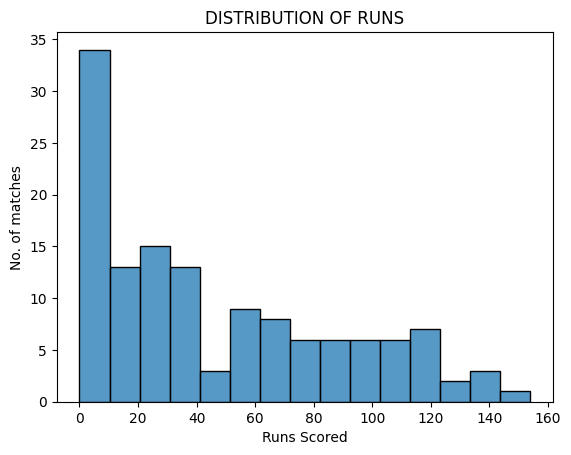

'The histogram shows the distribution of runs scored across matches.\nMost scores fall in the lower range, indicating that the player frequently scores below 40 runs.\nHowever, there are a few high scores above 100, showing the ability to play big innings.'

In [13]:
sns.histplot(df['Runs'],bins=15)
plt.xlabel('Runs Scored')
plt.ylabel('No. of matches')
plt.title('DISTRIBUTION OF RUNS')
plt.show()

'''The histogram shows the distribution of runs scored across matches.
Most scores fall in the lower range, indicating that the player frequently scores below 40 runs.
However, there are a few high scores above 100, showing the ability to play big innings.'''

## 3. Performance Trends:

Analyse the trend of runs scored over time. Use line plots to show the performance 
progression. 

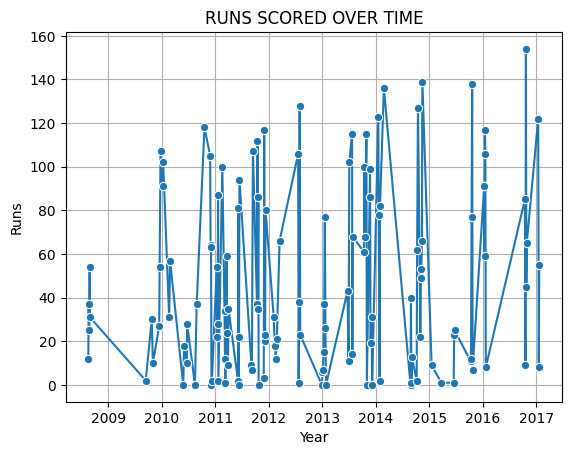

In [14]:
sns.lineplot(x='Start Date', y='Runs',data=df,marker="o")
plt.title("RUNS SCORED OVER TIME")
plt.xlabel("Year")
plt.grid()
plt.show()

#“Overall, the player shows variable performance with occasional high-scoring innings but lacks consistent scoring over time.”

Examine the trend of the strike rate over time. 

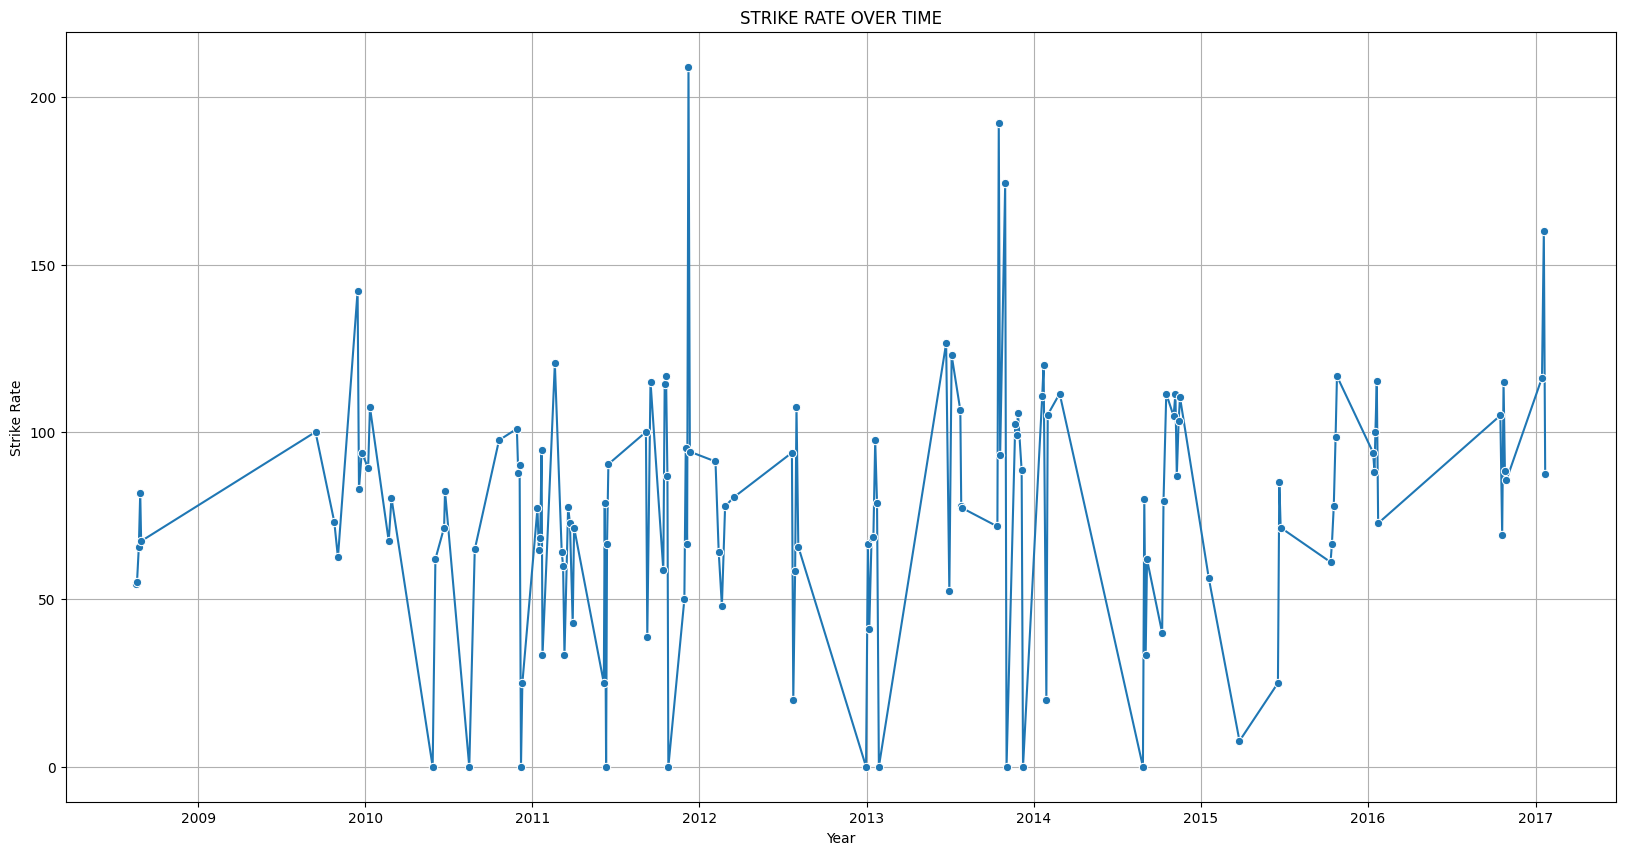

In [34]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Start Date', y='SR', data=df,marker="o")
plt.xlabel("Year")
plt.ylabel("Strike Rate")
plt.grid()
plt.title("STRIKE RATE OVER TIME")
plt.show()

#The player’s strike rate shows high fluctuations over time, indicating inconsistent but occasionally very aggressive performances

## 4. Positional Analysis:

Analyse performance based on batting positions (e.g., runs scored, strike rate). 

In [39]:
basis = df.groupby('Positions')[['Runs','SR']].mean().sort_values(by=['Runs','SR'],ascending=False)
np.ceil(basis)

,Runs,SR
Positions,,
3.0,50.0,75.0
4.0,49.0,83.0
5.0,41.0,74.0
1.0,37.0,72.0
6.0,23.0,210.0
2.0,17.0,44.0
7.0,10.0,92.0


Identify the most productive batting positions for Virat Kohli. 

In [17]:
df.groupby("Positions").agg({
    "Runs": "sum",
    "SR": "mean",
}).sort_values(by="Runs", ascending=False)

,Runs,SR
Positions,,
3.0,4477,74.620110
4.0,1370,82.916071
5.0,123,73.833333
1.0,110,71.660000
2.0,51,43.253333
7.0,30,91.810000
6.0,23,209.090000


## 5. Innings Analysis:

Compare his performance in the 1st and 2nd innings (e.g., runs scored, strike rate).

In [18]:
corr_betw_Inn = df.groupby('Inns')[['Runs','SR']].mean().sort_values(by=['Runs','SR'],ascending=False)
np.ceil(corr_betw_Inn)                                                                    

,Runs,SR
Inns,,
2,51.0,79.0
1,42.0,76.0


Use box plots to visualize the distribution of runs and strike rate in both innings. 

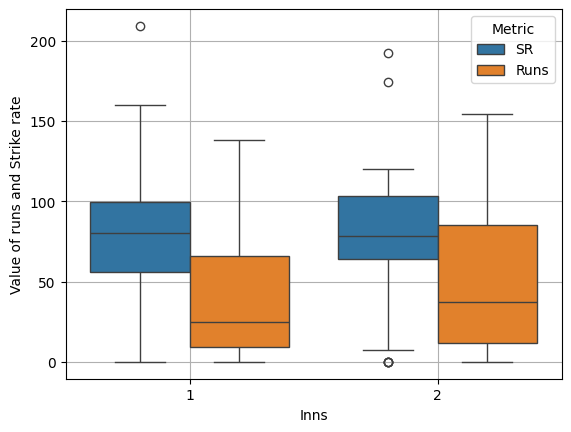

'The player shows slightly better and more aggressive performance (higher runs and strike rate) in the 2nd innings compared to the 1st innings,\nthough variability exists.'

In [37]:
df_melt = df.melt(id_vars='Inns', value_vars=['SR','Runs'],
                  var_name='Metric', value_name='Value')

sns.boxplot(x='Inns', y='Value', hue='Metric', data=df_melt)
plt.ylabel('Value of runs and Strike rate')
plt.grid()

plt.show()

'''The player shows slightly better and more aggressive performance (higher runs and strike rate) in the 2nd innings compared to the 1st innings,
though variability exists.'''

##  6. Opponent Analysis: 

 Determine his performance against different opponents (e.g., average runs scored, strike 
rate). 

In [20]:
opp_perf = df.groupby("Opposition")[["Runs","SR"]].mean().sort_values(by='Runs',ascending=True)
np.ceil(opp_perf)

,Runs,SR
Opposition,,
v Pakistan,6.0,38.0
v Netherlands,12.0,60.0
v Ireland,34.0,65.0
v South Africa,38.0,69.0
v England,40.0,77.0
v Zimbabwe,43.0,65.0
v Sri Lanka,46.0,79.0
v Australia,50.0,83.0
v West Indies,54.0,83.0


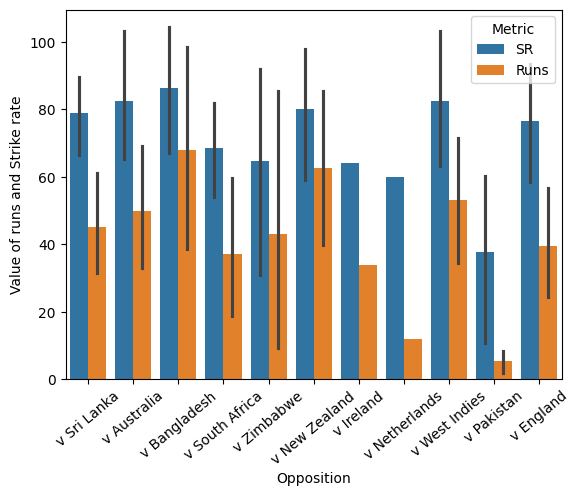

'“The graph compares runs scored and strike rate against different opponents.\nThe player generally maintains a higher strike rate across teams, indicating an aggressive batting style.\nHowever, runs scored vary significantly, showing inconsistency in performance.'

In [21]:
df_melt = df.melt(id_vars='Opposition', value_vars=['SR','Runs'],
                  var_name='Metric', value_name='Value')

plt.xticks(rotation=40)
sns.barplot(x='Opposition', y='Value', hue='Metric', data= df_melt)
plt.ylabel('Value of runs and Strike rate')

plt.show()

#The black lines represent variation (consistency), showing that performance fluctuates across matches.”

'''“The graph compares runs scored and strike rate against different opponents.
The player generally maintains a higher strike rate across teams, indicating an aggressive batting style.
However, runs scored vary significantly, showing inconsistency in performance.'''

Identify his most and least successful opponents. 

In [22]:
opponent = df.groupby("Opposition")["Runs"].mean().sort_values()
np.ceil(opponent)

Opposition
v Pakistan         6.0
v Netherlands     12.0
v Ireland         34.0
v South Africa    38.0
v England         40.0
v Zimbabwe        43.0
v Sri Lanka       46.0
v Australia       50.0
v West Indies     54.0
v New Zealand     63.0
v Bangladesh      68.0
Name: Runs, dtype: float64

## 7. Venue Analysis: 

 Analyse his performance at different venues. 

In [40]:
venue_stats = df.groupby('Ground').agg(
    Total_Runs=('Runs', 'sum'),
    Avg_StrikeRate=('SR', 'mean')
).reset_index()
venue_stats.head()

,Ground,Total_Runs,Avg_StrikeRate
0,Adelaide,18,64.280000
1,Ahmedabad,150,82.755000
2,Bengaluru,34,21.383333
3,Birmingham,44,79.900000
4,Brisbane,71,68.025000


In [24]:
venue_stats.max()

Ground            Wellington
Total_Runs               408
Inningss                   7
Avg_StrikeRate       137.875
dtype: object

In [25]:
venue_stats.min()

Ground            Adelaide
Total_Runs               0
Inningss                 1
Avg_StrikeRate         0.0
dtype: object

Identify venues where he performed exceptionally well or poorly

In [26]:
well = df[['Ground','Runs']].sort_values(by='Runs').max()
poor = df[['Ground','Runs']].sort_values(by='Runs').min()

print(well,poor)
# He played well in wellington and poor in Adelaide

Ground    Wellington
Runs             154
dtype: object Ground    Adelaide
Runs             0
dtype: object


## 8. Dismissal Analysis

Analyse the different modes of dismissals and their frequency.

In [27]:
df[df['Dismissal'] != 'Not Out']['Dismissal'].value_counts()

Dismissal
caught        84
not out       17
run out       10
bowled        10
lbw            9
stumped        1
hit wicket     1
Name: count, dtype: int64

In [28]:
dismissal_percent = df["Dismissal"].value_counts(normalize=True) * 100
np.round(dismissal_percent,2)

Dismissal
caught        63.64
not out       12.88
run out        7.58
bowled         7.58
lbw            6.82
stumped        0.76
hit wicket     0.76
Name: proportion, dtype: float64

Determine if there is a pattern in how he gets out. 

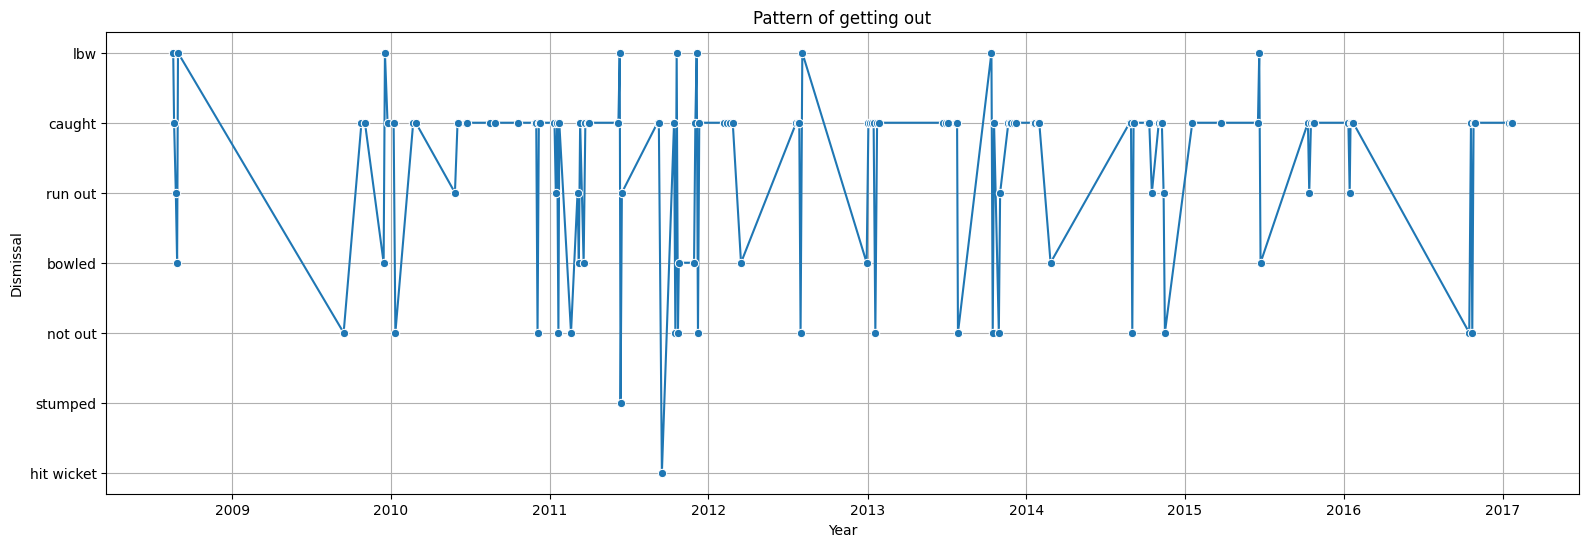

In [35]:
plt.figure(figsize=(19,6))
sns.lineplot(x='Start Date', y='Dismissal', data = df, marker="o")
plt.xlabel('Year')
plt.grid()
plt.title('Pattern of getting out')
plt.show()

#The player most frequently gets out caught across the years, with no clear time-based pattern in dismissals.

## 9. Boundary Analysis

Calculate the total number of 4s and 6s hit in the given period. 

In [30]:
df.groupby('Year')[['4s','6s']].sum().sort_values(by=['4s','6s'],ascending=False)
#Highest 4s in 2011 and 6s in 2013 and 2014

,4s,6s
Year,,
2011,121,7
2013,120,19
2014,89,19
2010,69,4
2016,62,8
2012,36,1
2009,26,1
2008,21,1
2017,18,5


 Analyse the frequency of boundaries per match and per opponent

In [31]:
df['Boundaries'] = df['4s'] + df['6s']
df

,Runs,BF,4s,6s,SR,Positions,Dismissal,Inns,Opposition,Ground,Start Date,Year,Boundaries
0,12,22,1,0,54.54,2.0,lbw,1,v Sri Lanka,Dambulla,2008-08-18,2008,1
1,37,67,6,0,55.22,2.0,caught,2,v Sri Lanka,Dambulla,2008-08-20,2008,6
2,25,38,4,0,65.78,1.0,run out,1,v Sri Lanka,Colombo (RPS),2008-08-24,2008,4
3,54,66,7,0,81.81,1.0,bowled,1,v Sri Lanka,Colombo (RPS),2008-08-27,2008,7
4,31,46,3,1,67.39,1.0,lbw,2,v Sri Lanka,Colombo (RPS),2008-08-29,2008,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,45,51,2,1,88.23,3.0,caught,2,v New Zealand,Ranchi,2016-10-26,2016,3
128,65,76,2,1,85.52,3.0,caught,1,v New Zealand,Visakhapatnam,2016-10-29,2016,3
129,122,105,8,5,116.19,3.0,caught,2,v England,Pune,2017-01-15,2017,13
130,8,5,2,0,160.00,3.0,caught,1,v England,Cuttack,2017-01-19,2017,2


In [32]:
df.groupby('Opposition')['Boundaries'].sum().sort_values()
#Highest boundary against Sri Lanka and Lowest against Pakistan

Opposition
v Pakistan          2
v Netherlands       2
v Ireland           3
v Zimbabwe         23
v South Africa     46
v Bangladesh       56
v New Zealand      92
v England          92
v Australia       108
v West Indies     108
v Sri Lanka       117
Name: Boundaries, dtype: int64

## 10. Advanced Insights:

Use statistical tests to determine if there is a significant difference in performance across 
different batting positions or innings

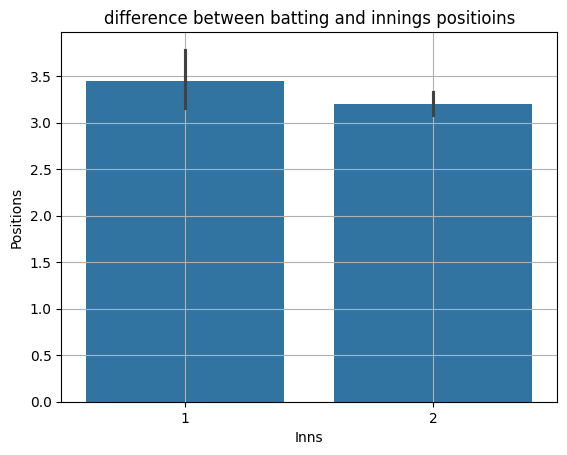

In [33]:
sns.barplot(x='Inns',y='Positions',data=df)
plt.grid()
plt.title('difference between batting and innings positioins')
plt.show()

#The player bats slightly higher in the 2nd innings compared to the 1st innings